# Reto 03 — Q-Learning: exploración vs. explotación

**Curso:** Aprendizaje por Refuerzo — Universidad EIA  
**Integrantes:** Simon Garces  
**Correos:** simon.garces@eia.edu.co  
**Fecha:** 2026-08-05  

> **Pregunta guía:** ¿cómo cambia el aprendizaje de una política cuando Q-Learning usa ε-greedy, ε-greedy con inicialización optimista, UCB o Softmax en entornos con distinta estructura de recompensas?

## Objetivos

- Implementar Q-Learning tabular respetando la API de Gymnasium.
- Separar la actualización de valor de la estrategia de selección.
- Comparar cuatro mecanismos de exploración bajo condiciones reproducibles.
- Evaluar aprendizaje, estabilidad y desempeño de la política final.
- Sustentar decisiones con métricas, gráficas y evidencia experimental.

## Organización en dos clases

### Clase 1 — Construcción y verificación

1. Reconocer `FrozenLake-v1`, `Blackjack-v1` y `Taxi-v4`.
2. Implementar las cuatro estrategias de selección.
3. Implementar el ciclo de Q-Learning y sus pruebas unitarias pequeñas.
4. Ejecutar un experimento piloto en FrozenLake.

**Hito al terminar:** las funciones pasan las verificaciones y una corrida produce curvas coherentes.

### Clase 2 — Experimento y comunicación

1. Ejecutar la comparación principal en los tres escenarios.
2. Evaluar las políticas sin exploración.
3. Realizar sensibilidad de hiperparámetros.
4. Interpretar resultados, documentar IA y redactar conclusiones.

**Hito al terminar:** tabla resumen, visualizaciones, respuestas y conclusiones completas.


## 1. Preparación del entorno


In [12]:
from __future__ import annotations

from collections.abc import Callable

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

SEED = 2026
ALPHA = 0.10
GAMMA = 0.99
N_RUNS = 30

ENV_CONFIG = {
    "FrozenLake-v1": {"episodes": 2_000, "max_steps": 100, "kwargs": {"is_slippery": True}},
    "Blackjack-v1": {"episodes": 10_000, "max_steps": 100, "kwargs": {"sab": True}},
    "Taxi-v4": {"episodes": 2_000, "max_steps": 200, "kwargs": {}},
}

STRATEGIES = {
    "epsilon_greedy": {"epsilon": 0.10, "q0": 0.0},
    "optimistic": {"epsilon": 0.01, "q0": 5.0},
    "ucb": {"c": 1.0, "q0": 0.0},
    "softmax": {"temperature": 0.50, "q0": 0.0},
}


## 2. Reconocimiento de los escenarios

Para cada entorno, reporte número de estados y acciones, rango de recompensas, condición terminal y dificultad esperada. Observe que `reset()` devuelve `(observation, info)` y `step()` devuelve `(observation, reward, terminated, truncated, info)`. Un episodio termina si `terminated or truncated`. Blackjack devuelve una tupla, por lo que se suministra una codificación tabular reproducible.


In [13]:
def tabular_space_size(observation_space) -> int:
    """Número de estados de un espacio Discrete o Tuple de Discrete."""
    if isinstance(observation_space, gym.spaces.Discrete):
        return int(observation_space.n)
    if isinstance(observation_space, gym.spaces.Tuple):
        return int(np.prod([space.n for space in observation_space.spaces]))
    raise TypeError("Este reto solo admite observaciones discretas.")


def encode_observation(observation, observation_space) -> int:
    """Convierte una observación discreta, incluida una tupla, en un índice."""
    if isinstance(observation_space, gym.spaces.Discrete):
        return int(observation)
    dimensions = tuple(space.n for space in observation_space.spaces)
    return int(np.ravel_multi_index(tuple(observation), dimensions))


for env_id, config in ENV_CONFIG.items():
    env = gym.make(env_id, **config["kwargs"])
    observation, info = env.reset(seed=SEED)
    print(env_id, "| estados tabulares:", tabular_space_size(env.observation_space), "| acciones:", env.action_space.n)
    print("  observación inicial:", observation, "| acciones válidas:", list(range(env.action_space.n)))
    env.close()


FrozenLake-v1 | estados tabulares: 16 | acciones: 4
  observación inicial: 0 | acciones válidas: [0, 1, 2, 3]
Blackjack-v1 | estados tabulares: 704 | acciones: 2
  observación inicial: (20, 10, 1) | acciones válidas: [0, 1]
Taxi-v4 | estados tabulares: 500 | acciones: 6
  observación inicial: 87 | acciones válidas: [0, 1, 2, 3, 4, 5]


### Análisis previo

Complete antes de entrenar:

| Entorno | Estados | Acciones | Recompensas relevantes | ¿Qué dificulta explorar? |
|---|---:|---:|---|---|
| FrozenLake-v1 | TODO | TODO | TODO | TODO |
| Blackjack-v1 | TODO | TODO | TODO | TODO |
| Taxi-v4 | TODO | TODO | TODO | TODO |


## 3. Estrategias de exploración

Todas las funciones deben devolver una acción válida y resolver empates aleatoriamente. `counts[s, a]` registra cuántas veces se eligió la acción `a` en el estado `s`.

- **ε-greedy:** acción aleatoria con probabilidad ε; en otro caso, una acción greedy.
- **ε-greedy optimista:** misma regla, pero la tabla inicia en `Q0 > 0`; explique por qué esto incentiva explorar.
- **UCB:** seleccione primero acciones no visitadas; luego maximice `Q(s,a) + c sqrt(log(N(s)+1) / N(s,a))`.
- **Softmax:** muestree según `softmax(Q(s,·)/τ)` usando estabilización numérica.


In [14]:
def random_argmax(values: np.ndarray, rng: np.random.Generator) -> int:
    """Devuelve aleatoriamente uno de los índices con valor máximo."""
    # np.asarray no copia si "values" ya es un arreglo de NumPy: solo asegura
    # la interfaz. Nunca escribimos sobre él, así que el arreglo del llamador
    # queda intacto (contrato: "no modifica el arreglo recibido").
    values = np.asarray(values)

    # values == values.max() arma una máscara booleana con True en TODAS las
    # posiciones que empatan en el máximo, y np.flatnonzero devuelve los
    # índices de esos True:
    #     [1.0, 3.0, 3.0, 0.0]  ->  [F, T, T, F]  ->  array([1, 2])
    best_actions = np.flatnonzero(values == values.max())

    # Elegimos uniformemente entre las acciones empatadas. Con np.argmax
    # siempre saldría el índice 1 y ese sesgo sistemático hacia la primera
    # acción del empate rompería la exploración.
    return int(rng.choice(best_actions))


# Estrategias admitidas. Tenerlas en un conjunto permite validar el argumento
# con un mensaje claro en vez de fallar más adelante de forma silenciosa.
VALID_STRATEGIES = frozenset({"epsilon_greedy", "optimistic", "ucb", "softmax"})


def select_action(
    q: np.ndarray,
    counts: np.ndarray,
    state: int,
    strategy: str,
    rng: np.random.Generator,
    *,
    epsilon: float = 0.10,
    c: float = 1.0,
    temperature: float = 0.50,
) -> int:
    """Selecciona una acción usando la estrategia solicitada."""
    # --- Validaciones exigidas por el contrato del reto -------------------
    if strategy not in VALID_STRATEGIES:
        raise ValueError(f"Estrategia desconocida: {strategy!r}")
    if not 0.0 <= epsilon <= 1.0:
        raise ValueError(f"epsilon debe estar en [0, 1]; se recibió {epsilon}")
    if c < 0.0:
        raise ValueError(f"c debe ser >= 0; se recibió {c}")
    if temperature <= 0.0:
        raise ValueError(f"temperature debe ser > 0; se recibió {temperature}")

    # Solo se usa la FILA del estado actual. q[state] es una vista (no copia),
    # pero únicamente la leemos: ni q ni counts se modifican aquí.
    q_state = q[state]
    n_actions = q_state.shape[0]

    # --- ε-greedy y optimista --------------------------------------------
    # Comparten exactamente la misma regla de selección; lo que las distingue
    # es el valor inicial Q0 de la tabla, que se fija en train_q_learning.
    if strategy in ("epsilon_greedy", "optimistic"):
        if rng.random() < epsilon:
            # Exploración: acción uniforme entre TODAS las acciones (incluida
            # la codiciosa, tal como define el algoritmo estándar).
            return int(rng.integers(n_actions))
        return random_argmax(q_state, rng)

    # --- UCB por estado-acción -------------------------------------------
    if strategy == "ucb":
        counts_state = counts[state]

        # Primero se agotan las acciones nunca probadas EN ESTE ESTADO. Sin
        # esto, N(s,a) = 0 haría una división por cero en la raíz.
        unvisited = np.flatnonzero(counts_state == 0)
        if unvisited.size > 0:
            return int(rng.choice(unvisited))

        # N(s) es la suma sobre las acciones de ESTE estado: los conteos son
        # locales, nunca un contador global compartido entre estados.
        n_state = counts_state.sum()
        exploration_bonus = c * np.sqrt(np.log(n_state + 1) / counts_state)
        return random_argmax(q_state + exploration_bonus, rng)

    # --- Softmax (Boltzmann) ---------------------------------------------
    # Versión numéricamente estable: restar el máximo antes de exponenciar
    # evita desbordamiento cuando Q/τ es grande, y no altera el resultado
    # porque exp(x-m)/Σexp(x-m) == exp(x)/Σexp(x).
    logits = q_state / temperature
    weights = np.exp(logits - np.max(logits))
    probabilities = weights / weights.sum()
    return int(rng.choice(n_actions, p=probabilities))

#### Cómo funciona

**`random_argmax` — por qué no basta `np.argmax`.** `np.argmax` es determinista: ante un
empate siempre devuelve la posición más pequeña. Al inicio del entrenamiento la tabla Q está
llena de ceros, así que *todo* es empate y el agente repetiría siempre la acción 0.

```python
q_row = np.array([1.0, 3.0, 3.0, 0.0])
np.argmax(q_row)                       # -> 1, siempre
[random_argmax(q_row, rng) for _ in range(6)]   # -> mezcla de 1 y 2
```

**`select_action` — una sola fila.** Todas las ramas leen `q[state]`, nunca la tabla completa.
En Blackjack hay 704 estados declarados y muchos son inalcanzables; si UCB mirara la tabla
entera, esos estados fantasma contaminarían la decisión.

**El bono de UCB.** `c * sqrt(log(N(s)+1) / N(s,a))` crece cuando la acción `a` se ha probado
poco *en relación* con las visitas al estado `s`. Es un empate entre valor estimado y
desconocimiento:

```python
# N(s)=15, tres acciones probadas 5 veces y una nunca:
counts_state = np.array([5, 5, 5, 0])   # la acción 3 se elige de una vez
```

**Softmax y el truco del máximo.** `exp(800)` desborda a `inf` y `inf/inf` da `nan`. Restar el
máximo deja el mayor logit en `exp(0) = 1` y conserva las proporciones intactas.

### Pruebas pequeñas de selección


In [15]:
# Pruebas pequeñas de select_action. Un generador propio por prueba mantiene
# cada comprobación aislada y reproducible.
q_test = np.array([[1.0, 3.0, 3.0, 0.0]])
n_test = np.array([[5, 5, 5, 0]])
rng_test = np.random.default_rng(SEED)

# 1) Toda acción devuelta debe caer dentro del rango de columnas de q.
for strategy in sorted(VALID_STRATEGIES):
    actions = [
        select_action(q_test, n_test, 0, strategy, np.random.default_rng(SEED + k))
        for k in range(50)
    ]
    assert all(0 <= a < q_test.shape[1] for a in actions), strategy
    assert all(isinstance(a, int) for a in actions), strategy

# 2) Los empates (acciones 1 y 2 valen 3.0) no deben resolverse siempre igual.
#    Con epsilon=0 no hay exploración, así que toda la variación proviene del
#    desempate aleatorio de random_argmax.
greedy_choices = {
    select_action(q_test, n_test, 0, "epsilon_greedy", np.random.default_rng(k), epsilon=0.0)
    for k in range(50)
}
assert greedy_choices == {1, 2}, greedy_choices

# 3) UCB prueba primero la acción no visitada (N(s,a) = 0 en la columna 3),
#    aunque su valor Q sea el más bajo de la fila.
assert select_action(q_test, n_test, 0, "ucb", np.random.default_rng(SEED)) == 3

# 4) Misma semilla -> misma acción; el flujo aleatorio es reproducible.
for strategy in sorted(VALID_STRATEGIES):
    a1 = select_action(q_test, n_test, 0, strategy, np.random.default_rng(7))
    a2 = select_action(q_test, n_test, 0, strategy, np.random.default_rng(7))
    assert a1 == a2, strategy

# 5) Ni q ni counts se modifican: comparamos contra copias tomadas antes.
q_before, n_before = q_test.copy(), n_test.copy()
for strategy in sorted(VALID_STRATEGIES):
    select_action(q_test, n_test, 0, strategy, rng_test)
assert np.array_equal(q_test, q_before) and np.array_equal(n_test, n_before)

# 6) Hiperparámetros inválidos deben fallar con ValueError, no en silencio.
for kwargs in ({"epsilon": -0.1}, {"epsilon": 1.5}, {"c": -1.0}, {"temperature": 0.0}):
    try:
        select_action(q_test, n_test, 0, "ucb", rng_test, **kwargs)
    except ValueError:
        pass
    else:
        raise AssertionError(f"No se validó {kwargs}")

try:
    select_action(q_test, n_test, 0, "inexistente", rng_test)
except ValueError:
    pass
else:
    raise AssertionError("No se validó la estrategia")

print("Las 6 pruebas de select_action pasaron.")

Las 6 pruebas de select_action pasaron.


#### Cómo funciona

Cada prueba ataca una cláusula del contrato del §7 del enunciado. Dos detalles del diseño:

**Semilla nueva por muestra, no un generador compartido.** Para probar el desempate se crean
50 generadores distintos (`default_rng(k)`) en vez de llamar 50 veces al mismo. Así cada
llamada es un experimento independiente y la prueba no depende del punto del flujo aleatorio
en que quedó la anterior.

**`assert` vs. `try/except`.** Para verificar que algo *falla* no sirve `assert`: hay que
capturar la excepción. El `else` de un `try` se ejecuta solo si **no** hubo excepción, que es
justo el caso que queremos denunciar:

```python
try:
    select_action(..., epsilon=-0.1)
except ValueError:
    pass                 # correcto: validó
else:
    raise AssertionError # la llamada pasó cuando debía fallar
```

## 4. Q-Learning tabular

Implemente la actualización:

$$Q(S_t,A_t) \leftarrow Q(S_t,A_t) + \alpha [R_{t+1} + \gamma(1-d)\max_a Q(S_{t+1},a)-Q(S_t,A_t)],$$

donde `d` es verdadero cuando la transición termina el MDP (`terminated`). Para un truncamiento por límite de tiempo, documente si realiza *bootstrap* y mantenga la decisión consistente. No actualice hacia el valor del estado terminal.


In [16]:
# Definición explícita de "éxito" por entorno (§10 del enunciado). Cada regla
# recibe el retorno total del episodio, la última recompensa y si el episodio
# terminó de verdad (terminated) o se cortó por límite de pasos (truncated).
SUCCESS_RULES = {
    # Llegar a la meta es la única transición que otorga recompensa.
    "FrozenLake-v1": lambda total, last, terminated: bool(total >= 1.0),
    # Ganar la mano paga +1; empatar 0 y perder -1.
    "Blackjack-v1": lambda total, last, terminated: bool(total >= 1.0),
    # La entrega correcta es la recompensa terminal de +20; cualquier otro
    # final (o un truncamiento) no cuenta como éxito.
    "Taxi-v4": lambda total, last, terminated: bool(terminated and last > 0),
}


def train_q_learning(
    env_id: str,
    strategy: str,
    episodes: int,
    max_steps: int,
    alpha: float,
    gamma: float,
    seed: int,
    env_kwargs: dict | None = None,
    **strategy_params,
) -> tuple[np.ndarray, pd.DataFrame, np.ndarray]:
    """Entrena Q-Learning y devuelve Q, historial por episodio y conteos."""
    if strategy not in VALID_STRATEGIES:
        raise ValueError(f"Estrategia desconocida: {strategy!r}")
    if episodes <= 0 or max_steps <= 0:
        raise ValueError("episodes y max_steps deben ser positivos.")
    if not 0.0 < alpha <= 1.0:
        raise ValueError(f"alpha debe estar en (0, 1]; se recibió {alpha}")
    if not 0.0 <= gamma <= 1.0:
        raise ValueError(f"gamma debe estar en [0, 1]; se recibió {gamma}")

    # q0 describe la INICIALIZACIÓN de la tabla, no la selección: se separa de
    # los parámetros que viajan a select_action (epsilon, c, temperature).
    strategy_params = dict(strategy_params)
    q0 = float(strategy_params.pop("q0", 0.0))

    # Cada corrida construye su propio entorno y su propio generador. No se
    # comparten objetos entre estrategias: solo se comparte la SEMILLA.
    env = gym.make(env_id, **(env_kwargs or {}))
    rng = np.random.default_rng(seed)
    success_rule = SUCCESS_RULES[env_id]

    try:
        n_states = tabular_space_size(env.observation_space)
        n_actions = int(env.action_space.n)

        q = np.full((n_states, n_actions), q0, dtype=float)
        counts = np.zeros((n_states, n_actions), dtype=np.int64)
        history = []

        for episode in range(episodes):
            # Se siembra el entorno UNA sola vez, en el primer reset. Sembrar
            # en cada episodio repetiría siempre la misma partida y anularía
            # la estocasticidad de FrozenLake o del mazo de Blackjack.
            if episode == 0:
                observation, _ = env.reset(seed=seed)
            else:
                observation, _ = env.reset()

            state = encode_observation(observation, env.observation_space)
            total_reward = 0.0
            td_errors = []
            last_reward = 0.0
            terminated = False

            for _ in range(max_steps):
                action = select_action(q, counts, state, strategy, rng, **strategy_params)
                observation, reward, terminated, truncated, _ = env.step(action)
                next_state = encode_observation(observation, env.observation_space)

                # Exactamente un incremento por transición.
                counts[state, action] += 1

                # Sin bootstrap desde un estado terminal: si terminated, el
                # objetivo es solo la recompensa. Ante TRUNCAMIENTO sí se hace
                # bootstrap, porque el episodio se cortó por un límite externo
                # y el valor futuro del estado sigue siendo válido.
                bootstrap = 0.0 if terminated else q[next_state].max()
                target = reward + gamma * bootstrap

                td_error = target - q[state, action]
                q[state, action] += alpha * td_error   # solo el par visitado

                td_errors.append(abs(td_error))
                total_reward += float(reward)
                last_reward = float(reward)
                state = next_state

                # El ciclo termina con terminated O truncated, sin excepción.
                if terminated or truncated:
                    break

            history.append(
                {
                    "episode": episode,
                    "return": total_reward,
                    "length": len(td_errors),
                    "success": success_rule(total_reward, last_reward, terminated),
                    # Magnitud media del error TD: sirve como diagnóstico de
                    # convergencia (debería decrecer si el aprendizaje avanza).
                    "td_error_mean": float(np.mean(td_errors)),
                }
            )
    finally:
        # finally garantiza el cierre del entorno incluso si algo falla arriba.
        env.close()

    return q, pd.DataFrame(history), counts

#### Cómo funciona

**La actualización, línea por línea.** La regla del §4 del enunciado se traduce casi
literalmente:

```python
bootstrap = 0.0 if terminated else q[next_state].max()   # el (1-d) de la fórmula
target    = reward + gamma * bootstrap                   # R + γ(1-d)·max_a Q(s',a)
td_error  = target - q[state, action]                    # el corchete completo
q[state, action] += alpha * td_error                     # Q ← Q + α[...]
```

`q[state, action] += ...` toca **una sola celda** de la tabla: Q-Learning tabular no
generaliza a otros pares estado-acción.

**`terminated` vs. `truncated` — la decisión que hay que documentar.** El bootstrap se apaga
solo con `terminated`. Si el episodio se corta por `max_steps` (`truncated`), el estado
alcanzado no es terminal: el juego habría continuado, así que su valor estimado sigue siendo
información legítima y **sí** se hace bootstrap. Poner `0.0` también en el truncamiento le
enseñaría al agente que el mundo se acaba a los 100 pasos, sesgando los valores hacia abajo.

**Por qué se siembra el entorno una sola vez.** `env.reset(seed=s)` reinicia el flujo aleatorio
del entorno. Llamarlo en cada episodio daría 2 000 episodios idénticos:

```python
env.reset(seed=s)   # episodio 0: fija el flujo
env.reset()         # episodios 1..N: continúan el flujo, partidas distintas
```

**`finally`.** Si `select_action` lanza `ValueError` a mitad del entrenamiento, el bloque
`finally` cierra igual el entorno; sin él quedarían entornos abiertos tras cada error.

### Contrato mínimo y verificaciones

Para una corrida corta compruebe:

- `Q.shape == (n_states, n_actions)` y todos sus valores son finitos.
- Hay exactamente una fila por episodio.
- `1 <= length <= max_steps`.
- `counts.sum()` coincide con el total de pasos registrados.
- La misma semilla reproduce resultados; otra semilla puede cambiarlos.
- Con `gamma=0`, el objetivo no contiene el valor del siguiente estado.
- Una transición terminal usa como objetivo únicamente la recompensa.


In [17]:
# Corrida corta para verificar el contrato de train_q_learning.
PILOT_KWARGS = ENV_CONFIG["FrozenLake-v1"]["kwargs"]
q_dbg, hist_dbg, counts_dbg = train_q_learning(
    "FrozenLake-v1", "epsilon_greedy", episodes=20, max_steps=100,
    alpha=ALPHA, gamma=GAMMA, seed=SEED, env_kwargs=PILOT_KWARGS, **STRATEGIES["epsilon_greedy"],
)

# Forma de la tabla y validez numérica.
assert q_dbg.shape == (16, 4), q_dbg.shape
assert np.all(np.isfinite(q_dbg)), "Q contiene NaN o infinitos."

# Una fila por episodio, con todas las columnas exigidas.
assert len(hist_dbg) == 20, len(hist_dbg)
assert list(hist_dbg.columns) == ["episode", "return", "length", "success", "td_error_mean"]

# Longitudes dentro del presupuesto de pasos.
assert hist_dbg["length"].between(1, 100).all()

# Los conteos suman exactamente el número de transiciones ejecutadas.
assert counts_dbg.sum() == hist_dbg["length"].sum(), (counts_dbg.sum(), hist_dbg["length"].sum())

# Reproducibilidad: misma semilla -> misma tabla y mismo historial.
q_rep, hist_rep, _ = train_q_learning(
    "FrozenLake-v1", "epsilon_greedy", episodes=20, max_steps=100,
    alpha=ALPHA, gamma=GAMMA, seed=SEED, env_kwargs=PILOT_KWARGS, **STRATEGIES["epsilon_greedy"],
)
assert np.array_equal(q_dbg, q_rep)
assert hist_dbg.equals(hist_rep)

# Otra semilla produce otra trayectoria. Ojo: en 20 episodios el agente casi
# nunca alcanza la meta, así que TODAS las recompensas son 0 y Q se queda en
# ceros con cualquier semilla. Comparar Q aquí no probaría nada; lo que sí
# cambia es el recorrido, visible en las longitudes de los episodios.
_, hist_alt, _ = train_q_learning(
    "FrozenLake-v1", "epsilon_greedy", episodes=20, max_steps=100,
    alpha=ALPHA, gamma=GAMMA, seed=SEED + 1, env_kwargs=PILOT_KWARGS, **STRATEGIES["epsilon_greedy"],
)
assert not hist_dbg["length"].equals(hist_alt["length"])

# Con suficientes episodios la meta sí se alcanza, Q deja de ser nula y
# entonces la semilla sí altera la tabla aprendida.
q_long_a, hist_long_a, _ = train_q_learning(
    "FrozenLake-v1", "epsilon_greedy", episodes=500, max_steps=100,
    alpha=ALPHA, gamma=GAMMA, seed=SEED, env_kwargs=PILOT_KWARGS, **STRATEGIES["epsilon_greedy"],
)
q_long_b, _, _ = train_q_learning(
    "FrozenLake-v1", "epsilon_greedy", episodes=500, max_steps=100,
    alpha=ALPHA, gamma=GAMMA, seed=SEED + 1, env_kwargs=PILOT_KWARGS, **STRATEGIES["epsilon_greedy"],
)
assert hist_long_a["success"].sum() > 0, "Sin recompensas no hay nada que comparar."
assert not np.array_equal(q_long_a, q_long_b)

# Con gamma = 0 el objetivo ignora el estado siguiente, así que Q solo puede
# ser distinto de cero donde se recibió recompensa. En FrozenLake la única
# recompensa es +1 al llegar a la meta.
q_g0, hist_g0, _ = train_q_learning(
    "FrozenLake-v1", "epsilon_greedy", episodes=200, max_steps=100,
    alpha=ALPHA, gamma=0.0, seed=SEED, env_kwargs=PILOT_KWARGS, **STRATEGIES["epsilon_greedy"],
)
assert np.all(q_g0 >= 0.0)
assert q_g0.max() <= 1.0, "Con gamma=0 ningún Q puede superar la recompensa máxima."

# Una transición terminal usa la recompensa como único objetivo: partiendo de
# Q=0 y alpha=1, el par que llega a la meta debe quedar exactamente en 1.0.
q_term, _, _ = train_q_learning(
    "FrozenLake-v1", "epsilon_greedy", episodes=500, max_steps=100,
    alpha=1.0, gamma=GAMMA, seed=SEED, env_kwargs=PILOT_KWARGS, epsilon=1.0, q0=0.0,
)
assert np.isclose(q_term.max(), 1.0), q_term.max()

print("Todas las verificaciones del contrato pasaron.")
print(hist_dbg.head())

Todas las verificaciones del contrato pasaron.
   episode  return  length  success  td_error_mean
0        0     0.0      10    False            0.0
1        1     0.0       4    False            0.0
2        2     0.0      13    False            0.0
3        3     0.0       3    False            0.0
4        4     0.0       9    False            0.0


#### Cómo funciona

**`counts.sum() == length.sum()` es la prueba más informativa.** Enlaza dos contadores
independientes: uno lo lleva `counts[state, action] += 1` dentro del bucle interno y el otro
sale de `len(td_errors)`. Si el incremento estuviera mal ubicado (por ejemplo, dentro de un
`if`, o después del `break`), los totales se separarían de inmediato.

**Las pruebas de semilla son complementarias.** La primera exige determinismo (misma semilla →
mismo resultado); la segunda exige que la semilla realmente *importe*. Una implementación que
ignorara `seed` pasaría la primera y fallaría la segunda.

**Por qué la segunda prueba compara historiales y no tablas.** La versión evidente —entrenar
con dos semillas y exigir `Q` distintas— **falla** con 20 episodios, y la causa es
instructiva: en ese presupuesto el agente no alcanza la meta ni una vez, todas las recompensas
valen 0, y `Q ← Q + α(0 + γ·0 − 0)` deja la tabla en ceros exactos sin importar la semilla.

```text
episodios    éxitos    max(Q)      ¿Q iguales entre semillas?
      20          0    0.000000    sí   <- recompensa escasa
     200          7    0.484898    no
     500         40    0.801033    no
```

Es la dificultad central de FrozenLake descrita en el §3.1 del enunciado: **recompensa escasa**.
Por eso la prueba corta compara `length` (las trayectorias sí difieren) y la comparación de
tablas se hace con 500 episodios, ya con éxitos acumulados.

**El truco de `alpha=1.0` y `epsilon=1.0`.** Con α = 1 la actualización deja de promediar y
*reemplaza* el valor: `Q ← target`. Si además la transición es terminal, `target = reward`
exactamente. Con ε = 1 el agente camina al azar, lo que garantiza que en 500 episodios alguna
vez tropiece con la meta:

```python
q[state, action] += 1.0 * (1.0 + 0.99 * 0.0 - 0.0)   # -> exactamente 1.0
```

Por eso `q_term.max()` debe ser `1.0` clavado, y no un valor cercano.

## 5. Evaluación sin exploración

Evaluar con la misma exploración usada durante el entrenamiento mezcla dos efectos. Implemente una evaluación separada que seleccione acciones greedy, no actualice `Q` y use semillas distintas a las de entrenamiento. En empates, conserve la selección aleatoria.


In [18]:
def evaluate_policy(
    env_id: str,
    q: np.ndarray,
    n_episodes: int,
    max_steps: int,
    seed: int,
    env_kwargs: dict | None = None,
) -> pd.DataFrame:
    """Evalúa la política greedy sin modificar Q."""
    if n_episodes <= 0 or max_steps <= 0:
        raise ValueError("n_episodes y max_steps deben ser positivos.")

    env = gym.make(env_id, **(env_kwargs or {}))
    rng = np.random.default_rng(seed)
    success_rule = SUCCESS_RULES[env_id]

    try:
        records = []
        for episode in range(n_episodes):
            if episode == 0:
                observation, _ = env.reset(seed=seed)
            else:
                observation, _ = env.reset()

            state = encode_observation(observation, env.observation_space)
            total_reward = 0.0
            length = 0
            last_reward = 0.0
            terminated = False

            for _ in range(max_steps):
                # Política greedy pura: sin epsilon, sin bono UCB y sin
                # muestreo softmax. Lo único aleatorio es el desempate, que
                # evita favorecer siempre la acción de menor índice.
                action = random_argmax(q[state], rng)

                observation, reward, terminated, truncated, _ = env.step(action)

                # Aquí NO hay actualización de Q: la evaluación solo mide.
                state = encode_observation(observation, env.observation_space)
                total_reward += float(reward)
                last_reward = float(reward)
                length += 1

                if terminated or truncated:
                    break

            records.append(
                {
                    "episode": episode,
                    "return": total_reward,
                    "length": length,
                    "success": success_rule(total_reward, last_reward, terminated),
                }
            )
    finally:
        env.close()

    return pd.DataFrame(records)


# La evaluación no debe alterar la tabla: se compara contra una copia previa.
q_eval_check = q_dbg.copy()
eval_dbg = evaluate_policy(
    "FrozenLake-v1", q_dbg, n_episodes=100, max_steps=100,
    seed=1_000_000 + SEED, env_kwargs=PILOT_KWARGS,
)
assert np.array_equal(q_dbg, q_eval_check), "evaluate_policy modificó Q."
assert len(eval_dbg) == 100
assert list(eval_dbg.columns) == ["episode", "return", "length", "success"]

print("evaluate_policy no altera Q. Tasa de éxito del piloto de 20 episodios:",
      eval_dbg["success"].mean())

evaluate_policy no altera Q. Tasa de éxito del piloto de 20 episodios: 0.02


#### Cómo funciona

**Entrenar y evaluar responden preguntas distintas.** El historial de entrenamiento mide el
desempeño *mientras el agente explora* — incluye todas las acciones malas que tomó a propósito
para aprender. `evaluate_policy` mide la política final: congela Q y actúa siempre greedy. Una
estrategia puede tener mala curva de entrenamiento (explora mucho) y aun así entregar la mejor
política final; el §13.2 del enunciado pregunta justamente por eso.

**Por qué el desempate sigue siendo aleatorio.** Ser greedy no obliga a ser determinista ante
empates. En FrozenLake muchos estados nunca se visitan y su fila queda en ceros; con `np.argmax`
el agente elegiría siempre «izquierda» ahí, lo que mide un artefacto del índice y no la política
aprendida.

**Familias de semillas separadas.** Entrenamiento usa `2026 + r` y evaluación `1_000_000 + 2026 + r`.
Si compartieran semilla, el agente sería evaluado exactamente en las partidas donde entrenó
—medición optimista y sin valor—. El desplazamiento grande evita además que las dos familias se
solapen para algún `r`.

## 6. Experimento piloto — cierre de la clase 1

Entrene las cuatro estrategias en `FrozenLake-v1` durante 300 episodios y una sola corrida. Grafique retorno y éxito suavizados con una media móvil de 50 episodios. Use este piloto para detectar errores; **no** lo presente como evidencia concluyente.


 epsilon_greedy | éxito entrenamiento: 0.270 | éxito evaluación: 0.660
     optimistic | éxito entrenamiento: 0.453 | éxito evaluación: 0.660
            ucb | éxito entrenamiento: 0.138 | éxito evaluación: 0.470
        softmax | éxito entrenamiento: 0.018 | éxito evaluación: 0.620


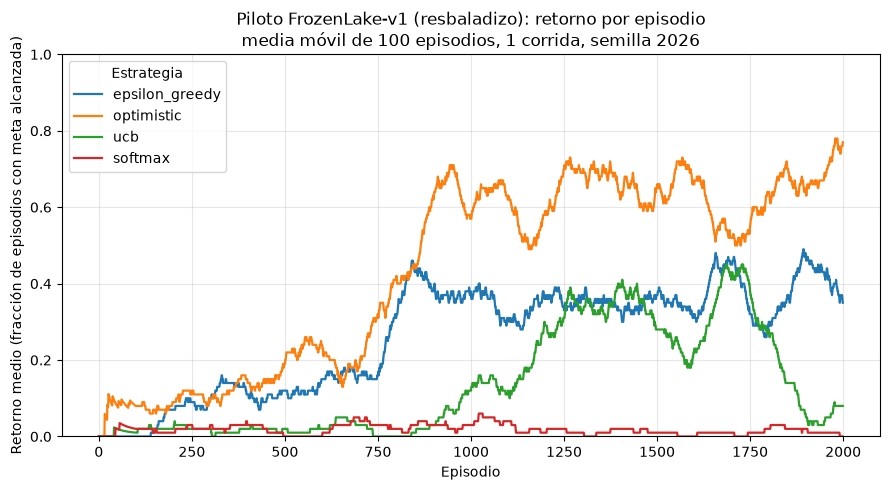

In [19]:
# Piloto de FrozenLake: una corrida por estrategia con el presupuesto real.
# Sirve para confirmar que las cuatro estrategias corren de extremo a extremo
# antes de lanzar el experimento completo de 30 corridas.
pilot_config = ENV_CONFIG["FrozenLake-v1"]
pilot_histories = {}

for strategy_name, params in STRATEGIES.items():
    q_pilot, history_pilot, _ = train_q_learning(
        "FrozenLake-v1",
        strategy_name,
        episodes=pilot_config["episodes"],
        max_steps=pilot_config["max_steps"],
        alpha=ALPHA,
        gamma=GAMMA,
        seed=SEED,
        env_kwargs=pilot_config["kwargs"],
        **params,
    )
    pilot_histories[strategy_name] = history_pilot

    evaluation_pilot = evaluate_policy(
        "FrozenLake-v1", q_pilot, n_episodes=100,
        max_steps=pilot_config["max_steps"], seed=1_000_000 + SEED,
        env_kwargs=pilot_config["kwargs"],
    )
    print(
        f"{strategy_name:>15} | éxito entrenamiento: {history_pilot['success'].mean():.3f}"
        f" | éxito evaluación: {evaluation_pilot['success'].mean():.3f}"
    )


# rolling() promedia una ventana móvil de episodios. La curva cruda de
# FrozenLake es una secuencia de 0 y 1 ilegible; el suavizado muestra la
# tendencia sin reemplazar los datos originales.
WINDOW = 100

fig, ax = plt.subplots(figsize=(9, 5))
for strategy_name, history_pilot in pilot_histories.items():
    smoothed = history_pilot["return"].rolling(WINDOW, min_periods=1).mean()
    ax.plot(history_pilot["episode"], smoothed, label=strategy_name, linewidth=1.6)

ax.set_title(
    f"Piloto FrozenLake-v1 (resbaladizo): retorno por episodio\n"
    f"media móvil de {WINDOW} episodios, 1 corrida, semilla {SEED}"
)
ax.set_xlabel("Episodio")
ax.set_ylabel("Retorno medio (fracción de episodios con meta alcanzada)")
ax.set_ylim(0, 1)
ax.legend(title="Estrategia")
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

#### Cómo funciona

**Qué valida el piloto y qué no.** Es **una** corrida por estrategia: sirve para comprobar que
todo corre de extremo a extremo y para tener una primera intuición, pero no autoriza ninguna
conclusión. En FrozenLake resbaladizo la varianza entre corridas es enorme, y por eso el §8 del
enunciado exige 30 corridas y el §10 un intervalo de confianza.

**`rolling(WINDOW).mean()`.** El retorno por episodio solo puede valer 0 o 1, así que graficarlo
crudo produce una franja sólida ilegible. La media móvil sobre 100 episodios lo convierte en
«tasa de éxito reciente»:

```python
serie.rolling(100, min_periods=1).mean()
# min_periods=1 evita NaN en los primeros 99 episodios,
# que se promedian con la ventana parcial disponible.
```

**Lectura de las dos métricas impresas.** «Éxito entrenamiento» incluye los episodios
arruinados por exploración deliberada; «éxito evaluación» mide la política congelada. Si la
segunda es muy superior a la primera, la estrategia estaba pagando un costo de exploración que
sí rindió.

## 7. Comparación principal — clase 2

Use los valores de `ENV_CONFIG`, al menos 30 corridas independientes y las mismas semillas por entorno para las cuatro estrategias. Esto empareja la aleatoriedad experimental sin reutilizar el mismo generador. Evalúe cada tabla final durante 100 episodios con semillas nuevas.

Registre por episodio: entorno, algoritmo, corrida, episodio, retorno, longitud, éxito y error TD medio. Registre por evaluación: retorno, longitud y éxito. Justifique cualquier reducción de corridas realizada por límites computacionales.


In [20]:
# Paleta categórica de las cuatro estrategias. El orden es fijo: cada estrategia
# conserva SIEMPRE su color en todas las figuras, aunque en alguna aparezcan
# menos series. Los hues salen de una paleta validada para daltonismo
# (separación CVD ΔE 9.2, visión normal ΔE 27.6 sobre fondo claro).
STRATEGY_COLORS = {
    "epsilon_greedy": "#2a78d6",   # azul
    "optimistic": "#eb6834",       # naranja
    "ucb": "#1baf7a",              # aqua
    "softmax": "#4a3aa7",          # violeta
}
STRATEGY_LABELS = {
    "epsilon_greedy": "ε-greedy (ε=0.10)",
    "optimistic": "optimista (Q₀=5, ε=0.01)",
    "ucb": "UCB (c=1)",
    "softmax": "Softmax (τ=0.50)",
}
ENV_LABELS = {
    "FrozenLake-v1": "FrozenLake-v1 (resbaladizo)",
    "Blackjack-v1": "Blackjack-v1 (sab)",
    "Taxi-v4": "Taxi-v4",
}


def run_experiment(
    env_config: dict,
    strategies: dict,
    n_runs: int = N_RUNS,
    base_seed: int = SEED,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Ejecuta entrenamiento y evaluación para todos los escenarios."""
    training_frames = []
    evaluation_frames = []

    for env_id, config in env_config.items():
        for strategy_name, params in strategies.items():
            for run in range(n_runs):
                # Las dos familias de semillas del §8. Cada estrategia recibe la
                # MISMA lista por entorno: lo que se comparte es el número, no el
                # generador (cada corrida crea el suyo dentro de train_q_learning).
                training_seed = base_seed + run
                evaluation_seed = 1_000_000 + base_seed + run

                q, history, _ = train_q_learning(
                    env_id,
                    strategy_name,
                    episodes=config["episodes"],
                    max_steps=config["max_steps"],
                    alpha=ALPHA,
                    gamma=GAMMA,
                    seed=training_seed,
                    env_kwargs=config["kwargs"],
                    **params,
                )
                training_frames.append(
                    history.assign(env=env_id, strategy=strategy_name, run=run)
                )

                # La política se congela y se mide con semillas de otra familia.
                evaluation = evaluate_policy(
                    env_id,
                    q,
                    n_episodes=100,
                    max_steps=config["max_steps"],
                    seed=evaluation_seed,
                    env_kwargs=config["kwargs"],
                )
                evaluation_frames.append(
                    evaluation.assign(env=env_id, strategy=strategy_name, run=run)
                )

        print(f"  {env_id:<16} listo ({len(strategies)} estrategias × {n_runs} corridas)")

    training = pd.concat(training_frames, ignore_index=True)
    evaluation = pd.concat(evaluation_frames, ignore_index=True)

    # "category" reduce muchísimo la memoria: en vez de guardar la cadena
    # "epsilon_greedy" en cada una de ~1.7 millones de filas, guarda un entero
    # pequeño y la tabla de nombres una sola vez.
    for frame in (training, evaluation):
        frame["env"] = frame["env"].astype("category")
        frame["strategy"] = frame["strategy"].astype("category")

    return training, evaluation

#### Cómo funciona

**Los tres bucles anidados son el diseño experimental.** `entorno × estrategia × corrida`. La
corrida es la unidad de repetición: 30 por combinación, porque una sola corrida de FrozenLake
resbaladizo no distingue una estrategia buena de una con suerte.

**Presupuesto idéntico, semillas idénticas.** Toda estrategia recibe los mismos `episodes`,
`max_steps`, `α`, `γ` y la misma lista de semillas. Lo único que varía es la regla de
selección, así que cualquier diferencia observada le es atribuible.

```python
training_seed   =         base_seed + run    # 2026, 2027, …
evaluation_seed = 1_000_000 + base_seed + run  # 1002026, 1002027, …
```

Las dos familias están separadas por un millón para que no se solapen nunca. Si se compartieran,
estarías evaluando al agente en las mismas partidas donde entrenó.

**Por qué `.astype("category")`.** El resultado tiene ~1.7 millones de filas. Guardar la cadena
`"epsilon_greedy"` en cada una gasta unos 60 bytes; como categoría gasta 1 byte más una tabla
de nombres. Es la diferencia entre unos 400 MB y unos 40 MB.

In [21]:
# Ejecución del experimento principal. Es la celda más lenta del notebook:
# 3 entornos × 4 estrategias × 30 corridas. Toma del orden de 20 a 40 minutos.
import time

start = time.perf_counter()
training_results, evaluation_results = run_experiment(ENV_CONFIG, STRATEGIES)
elapsed = time.perf_counter() - start

print(f"\nTiempo total: {elapsed / 60:.1f} minutos")
print(f"Filas de entrenamiento: {len(training_results):,}")
print(f"Filas de evaluación:    {len(evaluation_results):,}")

# Comprobación de que el diseño quedó balanceado: toda combinación
# entorno × estrategia debe tener exactamente N_RUNS corridas.
balance = (
    evaluation_results.groupby(["env", "strategy"], observed=True)["run"]
    .nunique()
    .unstack()
)
assert (balance == N_RUNS).all().all(), balance
print(f"\nDiseño balanceado: {N_RUNS} corridas en las 12 combinaciones.")

  FrozenLake-v1    listo (4 estrategias × 30 corridas)
  Blackjack-v1     listo (4 estrategias × 30 corridas)
  Taxi-v4          listo (4 estrategias × 30 corridas)

Tiempo total: 18.3 minutos
Filas de entrenamiento: 1,680,000
Filas de evaluación:    36,000

Diseño balanceado: 30 corridas en las 12 combinaciones.


## 8. Métricas y visualizaciones obligatorias

Construya una tabla por entorno y algoritmo con:

1. Retorno medio de entrenamiento en el último 10 % de episodios.
2. Área bajo la curva del retorno medio (calidad durante el aprendizaje).
3. Tasa de éxito final durante evaluación.
4. Retorno medio de evaluación.
5. Longitud media de evaluación.
6. Intervalo de confianza del 95 % entre corridas (indique el método).

Incluya, como mínimo:

- Curvas de retorno por episodio, media móvil y banda de IC 95 %.
- Curvas de éxito acumulado o móvil.
- Comparación del retorno de evaluación por entorno.
- Mapa de calor de `max_a Q(s,a)` o visualización de política para al menos un entorno.

No promedie directamente episodios de entornos con escalas de recompensa distintas en una única cifra global.


In [22]:
from scipy import stats


def mean_ci(values: np.ndarray, confidence: float = 0.95) -> tuple[float, float]:
    """Media y semiancho del intervalo de confianza entre corridas."""
    values = np.asarray(values, dtype=float)
    n = len(values)
    if n < 2:
        return float(values.mean()), float("nan")
    # Error estándar de la media = desviación muestral / sqrt(n). Se usa la t de
    # Student y no la normal porque n=30 es pequeño y sigma es desconocida.
    standard_error = values.std(ddof=1) / np.sqrt(n)
    half_width = standard_error * stats.t.ppf(0.5 + confidence / 2, df=n - 1)
    return float(values.mean()), float(half_width)


def summarize(training: pd.DataFrame, evaluation: pd.DataFrame) -> pd.DataFrame:
    """Las seis métricas obligatorias del §10, por entorno y estrategia."""
    rows = []
    for (env_id, strategy_name), train_group in training.groupby(
        ["env", "strategy"], observed=True
    ):
        eval_group = evaluation[
            (evaluation["env"] == env_id) & (evaluation["strategy"] == strategy_name)
        ]

        # Cada métrica se calcula PRIMERO dentro de cada corrida, y solo después
        # se promedia entre corridas. Así la corrida es la unidad estadística y
        # el intervalo de confianza mide variabilidad entre corridas, no entre
        # episodios (que están correlacionados dentro de una misma corrida).
        n_episodes = train_group["episode"].max() + 1
        tail_start = int(n_episodes * 0.90)

        per_run_tail = train_group[train_group["episode"] >= tail_start].groupby("run")["return"].mean()
        per_run_auc = train_group.groupby("run")["return"].mean()
        per_run_eval_success = eval_group.groupby("run")["success"].mean()
        per_run_eval_return = eval_group.groupby("run")["return"].mean()
        per_run_eval_length = eval_group.groupby("run")["length"].mean()

        record = {"env": env_id, "strategy": strategy_name}
        for name, series in [
            ("retorno_ultimo_10pct", per_run_tail),
            ("auc_retorno", per_run_auc),
            ("exito_eval", per_run_eval_success),
            ("retorno_eval", per_run_eval_return),
            ("longitud_eval", per_run_eval_length),
        ]:
            mean, half = mean_ci(series.to_numpy())
            record[name] = mean
            record[name + "_ic95"] = half
        rows.append(record)

    return pd.DataFrame(rows).sort_values(["env", "strategy"]).reset_index(drop=True)


summary = summarize(training_results, evaluation_results)

# Vista legible: media ± semiancho del IC 95 %.
display_table = summary[["env", "strategy"]].copy()
for column in ["retorno_ultimo_10pct", "auc_retorno", "exito_eval", "retorno_eval", "longitud_eval"]:
    display_table[column] = [
        f"{m:.3f} ± {h:.3f}" for m, h in zip(summary[column], summary[column + "_ic95"])
    ]

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 20)
print(f"Métricas obligatorias del §10 — media entre {N_RUNS} corridas ± IC 95 %\n")
display_table

Métricas obligatorias del §10 — media entre 30 corridas ± IC 95 %



,env,strategy,retorno_ultimo_10pct,auc_retorno,exito_eval,retorno_eval,longitud_eval
0,Blackjack-v1,epsilon_greedy,-0.113 ± 0.011,-0.129 ± 0.003,0.420 ± 0.022,-0.076 ± 0.040,1.543 ± 0.028
1,Blackjack-v1,optimistic,-0.152 ± 0.013,-0.227 ± 0.003,0.404 ± 0.022,-0.112 ± 0.039,1.462 ± 0.024
2,Blackjack-v1,softmax,-0.173 ± 0.011,-0.211 ± 0.003,0.427 ± 0.018,-0.065 ± 0.036,1.483 ± 0.023
3,Blackjack-v1,ucb,-0.113 ± 0.011,-0.147 ± 0.004,0.426 ± 0.020,-0.056 ± 0.039,1.531 ± 0.023
4,FrozenLake-v1,epsilon_greedy,0.386 ± 0.022,0.236 ± 0.021,0.701 ± 0.045,0.701 ± 0.045,40.488 ± 2.005
5,FrozenLake-v1,optimistic,0.682 ± 0.016,0.463 ± 0.003,0.733 ± 0.020,0.733 ± 0.020,44.184 ± 1.191
6,FrozenLake-v1,softmax,0.021 ± 0.004,0.017 ± 0.001,0.475 ± 0.071,0.475 ± 0.071,33.068 ± 2.994
7,FrozenLake-v1,ucb,0.417 ± 0.070,0.199 ± 0.022,0.582 ± 0.058,0.582 ± 0.058,47.780 ± 5.540
8,Taxi-v4,epsilon_greedy,1.838 ± 0.191,-54.626 ± 0.241,0.897 ± 0.013,-17.875 ± 4.878,31.919 ± 2.506
9,Taxi-v4,optimistic,6.443 ± 0.137,-50.269 ± 0.285,0.862 ± 0.011,-41.241 ± 9.501,38.371 ± 1.988


#### Cómo funciona

**Primero dentro de la corrida, después entre corridas.** Es la decisión estadística importante.
Los episodios de una misma corrida no son independientes —comparten la tabla Q que se va
formando—, así que promediarlos todos juntos daría un intervalo de confianza falsamente
estrecho. La secuencia correcta es: resumir cada corrida a **un** número, y tratar esos 30
números como la muestra.

**Por qué la t de Student y no 1.96.** Con `n = 30` y sigma desconocida, el multiplicador
correcto es `t(0.975, gl=29) ≈ 2.045`, no el 1.96 de la normal. La diferencia es pequeña aquí
pero es lo correcto, y con las 10 corridas del análisis de sensibilidad ya pesa (`t ≈ 2.262`).

```python
semiancho = (desviación / √n) · t(0.975, n−1)
```

**Las dos métricas de entrenamiento miden cosas distintas.** `retorno_ultimo_10pct` mira solo el
final: dónde terminó. `auc_retorno` promedia toda la curva: cuánto acumuló por el camino, así
que premia aprender rápido. Una estrategia puede ganar en una y perder en la otra — es
exactamente la tensión de la pregunta 1 contra la pregunta 9 del §13.

**No se mezclan entornos.** La tabla queda agrupada por `env` a propósito: promediar el retorno
de Taxi (escala ±20) con el de FrozenLake (escala 0–1) no significaría nada.

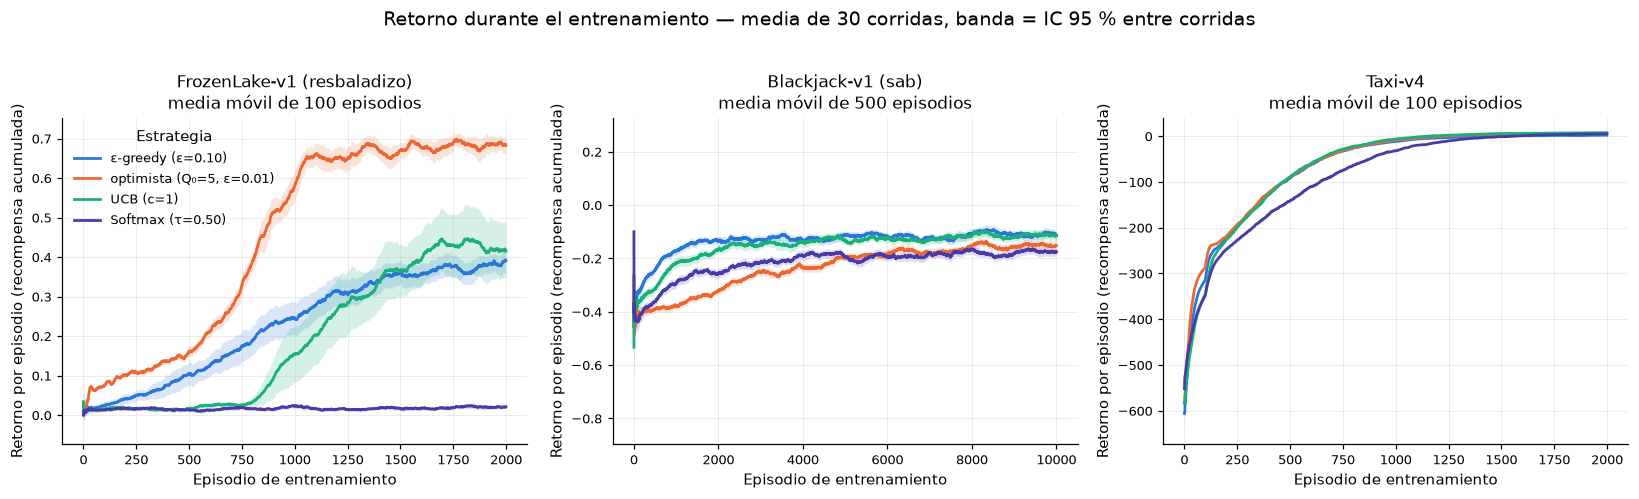

In [23]:
# Estilo común de las figuras. Ejes y rejilla deliberadamente discretos para que
# el color de las series sea lo único que compite por la atención.
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linewidth": 0.6,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 11,
    "axes.labelsize": 9.5,
    "legend.fontsize": 8.5,
    "xtick.labelsize": 8.5,
    "ytick.labelsize": 8.5,
})

SMOOTH_WINDOW = {"FrozenLake-v1": 100, "Blackjack-v1": 500, "Taxi-v4": 100}


def curve_with_ci(group: pd.DataFrame, column: str, window: int):
    """Curva media suavizada entre corridas y semiancho del IC 95 %."""
    # Una columna por corrida, una fila por episodio.
    wide = group.pivot_table(index="episode", columns="run", values=column)
    # Se suaviza CADA corrida por separado y solo después se agrega. Al revés
    # (agregar y luego suavizar) la banda saldría artificialmente estrecha.
    smoothed = wide.rolling(window, min_periods=1).mean()
    n_runs = smoothed.shape[1]
    mean = smoothed.mean(axis=1)
    half = (smoothed.std(axis=1, ddof=1) / np.sqrt(n_runs)) * stats.t.ppf(0.975, df=n_runs - 1)
    return mean, half


fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))

for ax, env_id in zip(axes, ENV_CONFIG):
    window = SMOOTH_WINDOW[env_id]
    subset = training_results[training_results["env"] == env_id]
    for strategy_name in STRATEGIES:
        group = subset[subset["strategy"] == strategy_name]
        mean, half = curve_with_ci(group, "return", window)
        color = STRATEGY_COLORS[strategy_name]
        ax.fill_between(mean.index, mean - half, mean + half, color=color, alpha=0.18, linewidth=0)
        ax.plot(mean.index, mean, color=color, linewidth=1.8, label=STRATEGY_LABELS[strategy_name])
    ax.set_title(f"{ENV_LABELS[env_id]}\nmedia móvil de {window} episodios")
    ax.set_xlabel("Episodio de entrenamiento")
    ax.set_ylabel("Retorno por episodio (recompensa acumulada)")

axes[0].legend(title="Estrategia", loc="upper left", frameon=False)
fig.suptitle(
    f"Retorno durante el entrenamiento — media de {N_RUNS} corridas, "
    f"banda = IC 95 % entre corridas",
    fontsize=12.5, y=1.02,
)
fig.tight_layout()
plt.show()

#### Figura 1 — Retorno por episodio

**Qué mira:** el desempeño *mientras el agente explora*. Incluye todas las acciones malas que
tomó a propósito para aprender, así que no es la calidad de la política final — eso lo mide la
figura 3.

**Cómo leerla.** La línea es la media de las 30 corridas; la banda es el IC 95 % **entre
corridas**, no entre episodios. Cuando dos bandas se solapan a lo largo del eje, la diferencia
entre esas estrategias no está respaldada por el experimento por más separadas que se vean las
líneas centrales.

**Las escalas verticales son distintas a propósito** y no deben compararse entre paneles:
FrozenLake vive en `[0,1]`, Blackjack en `[-1,1]` y Taxi llega a `+20`. Poner los tres en un
eje común aplastaría a los dos primeros.

**Sobre el suavizado.** El retorno crudo de FrozenLake solo vale 0 o 1, así que sin la media
móvil el panel sería una franja sólida ilegible. El suavizado es más ancho en Blackjack (500)
porque su recompensa terminal es mucho más ruidosa. La ventana **no reemplaza** los datos: la
banda de incertidumbre se calcula sobre las corridas suavizadas, no sobre la media.

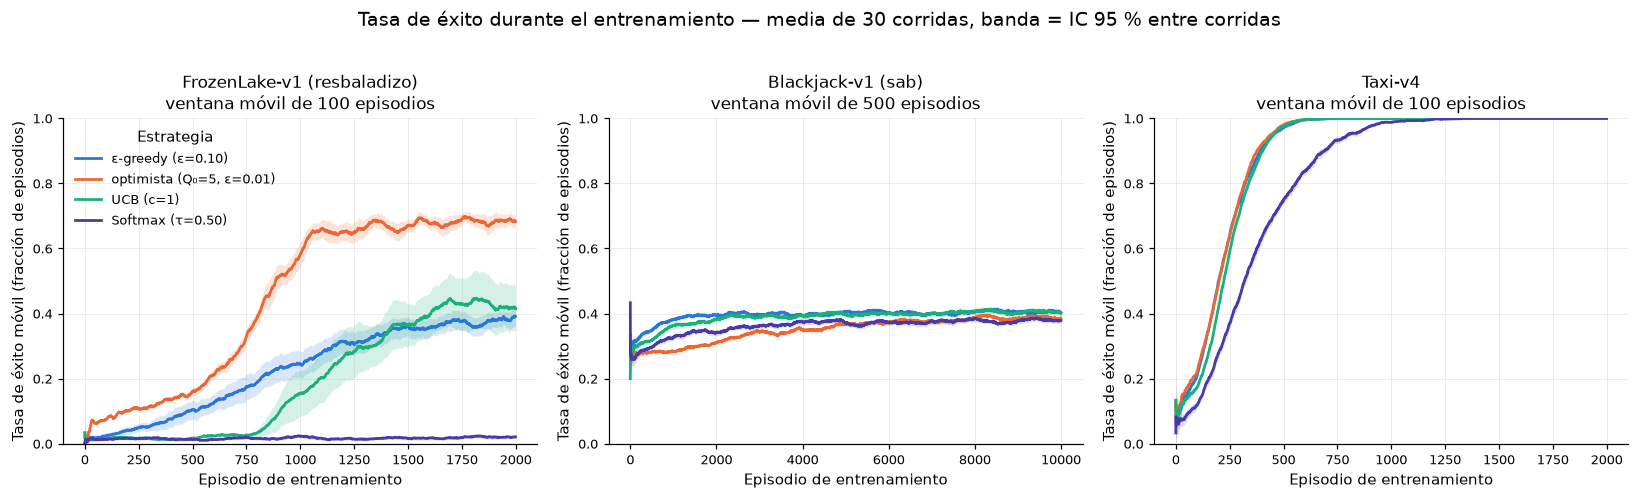

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))

for ax, env_id in zip(axes, ENV_CONFIG):
    window = SMOOTH_WINDOW[env_id]
    subset = training_results[training_results["env"] == env_id]
    for strategy_name in STRATEGIES:
        group = subset[subset["strategy"] == strategy_name]
        # "success" es booleano; su media móvil es directamente la tasa de éxito
        # reciente, entre 0 y 1, comparable entre los tres entornos.
        mean, half = curve_with_ci(group.assign(success=group["success"].astype(float)), "success", window)
        color = STRATEGY_COLORS[strategy_name]
        ax.fill_between(mean.index, mean - half, mean + half, color=color, alpha=0.18, linewidth=0)
        ax.plot(mean.index, mean, color=color, linewidth=1.8, label=STRATEGY_LABELS[strategy_name])
    ax.set_title(f"{ENV_LABELS[env_id]}\nventana móvil de {window} episodios")
    ax.set_xlabel("Episodio de entrenamiento")
    ax.set_ylabel("Tasa de éxito móvil (fracción de episodios)")
    ax.set_ylim(0, 1)

axes[0].legend(title="Estrategia", loc="upper left", frameon=False)
fig.suptitle(
    f"Tasa de éxito durante el entrenamiento — media de {N_RUNS} corridas, "
    f"banda = IC 95 % entre corridas",
    fontsize=12.5, y=1.02,
)
fig.tight_layout()
plt.show()

#### Figura 2 — Tasa de éxito móvil

**Por qué existe además de la figura 1.** El retorno y el éxito no son lo mismo en cuanto la
recompensa deja de ser 0/1. En Taxi un agente puede subir su retorno de −200 a −20 sin entregar
jamás un pasajero, solo dejando de chocar: la figura 1 mostraría una mejora enorme y esta
figura seguiría plana en cero. Aquí la escala es comparable entre los tres paneles porque
`success` siempre es una fracción entre 0 y 1.

**La definición de éxito la fijamos nosotros** en `SUCCESS_RULES`, y no es la misma en los tres
entornos: retorno ≥ 1 en FrozenLake y Blackjack, y recompensa terminal positiva en Taxi. Es la
exigencia del §10 del enunciado — "defina explícitamente `success` en cada entorno".

**Qué buscar:** la pendiente inicial dice quién aprende rápido (pregunta 1 del §13); la altura
final dice quién aprende mejor. Rara vez es la misma estrategia.

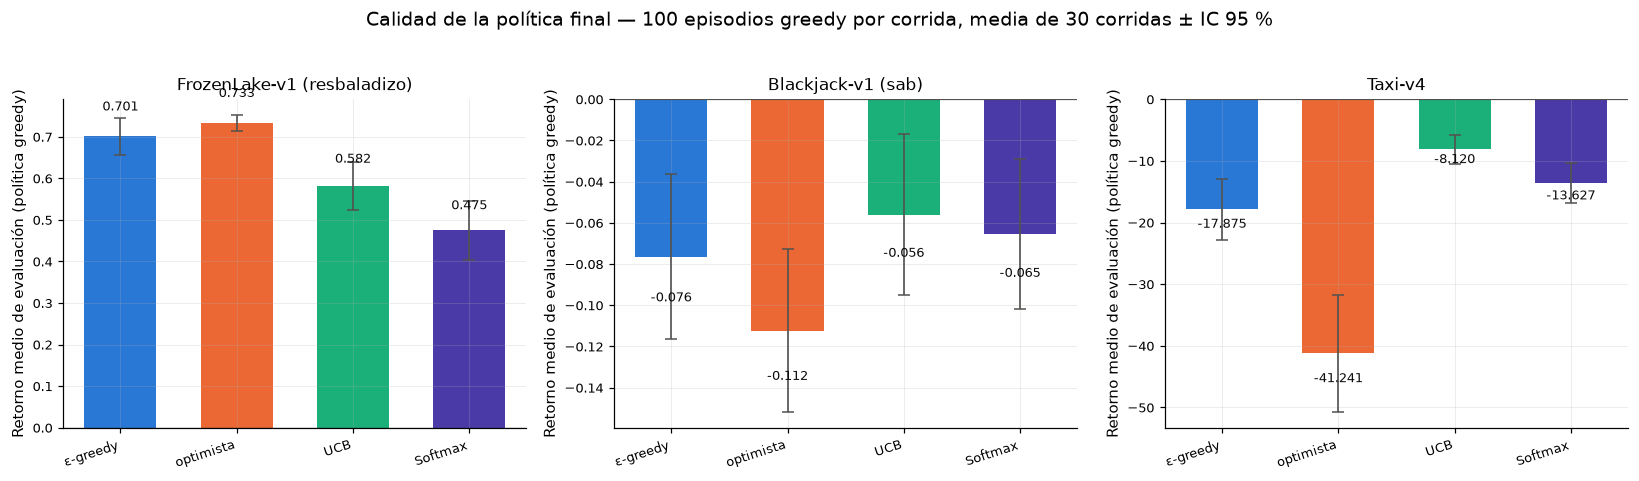

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
strategy_names = list(STRATEGIES)
x_positions = np.arange(len(strategy_names))

for ax, env_id in zip(axes, ENV_CONFIG):
    block = summary[summary["env"] == env_id].set_index("strategy").loc[strategy_names]
    colors = [STRATEGY_COLORS[s] for s in strategy_names]
    # yerr dibuja la barra de error; capsize le pone los topes horizontales.
    bars = ax.bar(
        x_positions, block["retorno_eval"], width=0.62, color=colors,
        yerr=block["retorno_eval_ic95"], capsize=4,
        error_kw={"ecolor": "#52514e", "elinewidth": 1.1},
    )
    # Etiqueta directa sobre cada barra: el valor exacto sin obligar a leer el eje.
    for bar, value, half in zip(bars, block["retorno_eval"], block["retorno_eval_ic95"]):
        offset = (abs(value) + half) * 0.06 + 0.01
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            value + (offset if value >= 0 else -offset),
            f"{value:.3f}", ha="center",
            va="bottom" if value >= 0 else "top",
            fontsize=8.5, color="#0b0b0b",
        )
    ax.axhline(0, color="#52514e", linewidth=0.8)
    ax.set_xticks(x_positions)
    ax.set_xticklabels([STRATEGY_LABELS[s].split(" (")[0] for s in strategy_names], rotation=18, ha="right")
    ax.set_title(ENV_LABELS[env_id])
    ax.set_ylabel("Retorno medio de evaluación (política greedy)")

fig.suptitle(
    f"Calidad de la política final — 100 episodios greedy por corrida, "
    f"media de {N_RUNS} corridas ± IC 95 %",
    fontsize=12.5, y=1.03,
)
fig.tight_layout()
plt.show()

#### Figura 3 — Retorno de evaluación

**Esta es la figura que responde "¿quién ganó?".** Las dos anteriores miden el camino; esta mide
el destino: la tabla Q congelada, jugando greedy, sin explorar, con semillas de una familia
distinta a la de entrenamiento.

**Cómo leer las barras de error.** Son IC 95 % sobre 30 corridas. Si las barras de dos
estrategias se solapan, **no puedes afirmar que una sea mejor** — es la diferencia entre "ganó
en mi tabla" y "ganó en el experimento". El §12 del enunciado pide justamente que la elección
se base en resultados agregados y no en una corrida favorable.

**Compara esta figura con la 1.** Si alguna estrategia queda mal en el entrenamiento y bien
aquí, estaba pagando un costo de exploración que rindió — y ahí tienes contestada la pregunta 2
del §13 con evidencia. Softmax fue la candidata a eso en el piloto.

**Escalas no comparables entre paneles**, otra vez: un 0.7 en FrozenLake y un 7 en Taxi no
guardan ninguna relación.

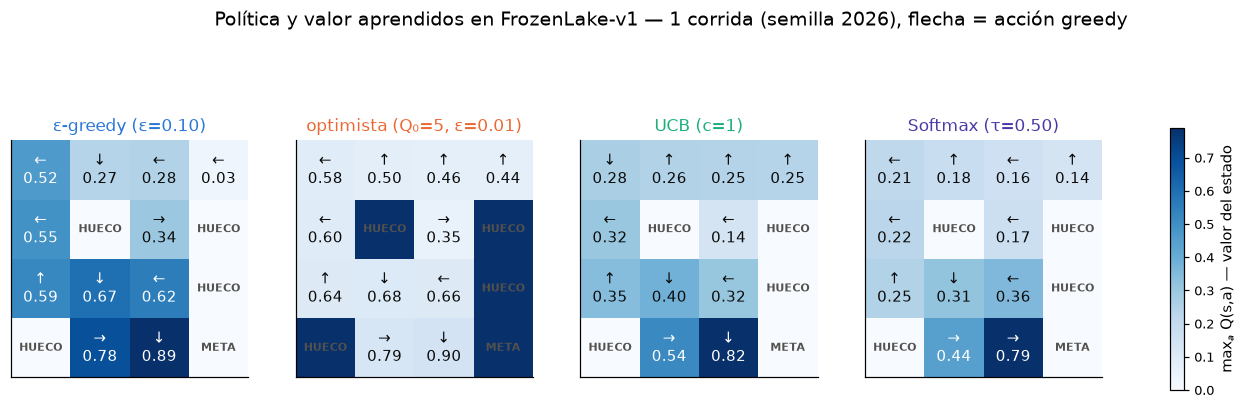

In [26]:
# Mapa de valor y política aprendida en FrozenLake. Se reentrena una corrida por
# estrategia (rápido) porque run_experiment no conserva las tablas Q.
lake_config = ENV_CONFIG["FrozenLake-v1"]
lake_map = gym.make("FrozenLake-v1", **lake_config["kwargs"]).unwrapped.desc.astype(str)
ARROWS = {0: "←", 1: "↓", 2: "→", 3: "↑"}

fig, axes = plt.subplots(1, 4, figsize=(16, 4.3))

for ax, (strategy_name, params) in zip(axes, STRATEGIES.items()):
    q_map, _, _ = train_q_learning(
        "FrozenLake-v1", strategy_name,
        episodes=lake_config["episodes"], max_steps=lake_config["max_steps"],
        alpha=ALPHA, gamma=GAMMA, seed=SEED,
        env_kwargs=lake_config["kwargs"], **params,
    )
    values = q_map.max(axis=1).reshape(4, 4)

    # Rampa secuencial de un solo hue (azul claro -> azul oscuro): codifica
    # MAGNITUD, por eso no se usa aquí la paleta categórica de las estrategias.
    image = ax.imshow(values, cmap="Blues", vmin=0, vmax=max(values.max(), 1e-9))

    for row in range(4):
        for col in range(4):
            state = row * 4 + col
            tile = lake_map[row, col]
            if tile in ("H", "G"):
                label = "HUECO" if tile == "H" else "META"
                ax.text(col, row, label, ha="center", va="center", fontsize=7.5,
                        color="#52514e", fontweight="bold")
                continue
            # Texto claro sobre celdas oscuras para conservar el contraste.
            shade = "#ffffff" if values[row, col] > values.max() * 0.55 else "#0b0b0b"
            ax.text(col, row, f"{ARROWS[int(q_map[state].argmax())]}\n{values[row, col]:.2f}",
                    ha="center", va="center", fontsize=10, color=shade)

    ax.set_title(STRATEGY_LABELS[strategy_name], color=STRATEGY_COLORS[strategy_name])
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)

fig.colorbar(image, ax=axes, shrink=0.72, label="max$_a$ Q(s,a) — valor del estado")
fig.suptitle(
    "Política y valor aprendidos en FrozenLake-v1 — 1 corrida (semilla 2026), "
    "flecha = acción greedy",
    fontsize=12.5, y=1.02,
)
plt.show()

#### Figura 4 — Mapa de valor y política

**Qué muestra cada celda:** la flecha es la acción greedy que el agente elegiría ahí, y el
número es `max_a Q(s,a)`, el valor del estado. El sombreado codifica ese mismo valor.

**Por qué el color aquí es azul y no los colores de las estrategias.** Es un encoding distinto:
las figuras 1–3 usan color **categórico** (identidad: qué estrategia), esta usa una rampa
**secuencial** de un solo hue (magnitud: cuánto vale el estado). Mezclar los dos roles haría
ilegible el mapa. La identidad de la estrategia la lleva el título de cada panel.

**La lectura importante.** El valor crece hacia la meta: es la asignación de crédito
propagándose hacia atrás desde la única casilla que paga. Si alguna estrategia deja casillas
oscuras lejos de los huecos, es que **no exploró esa zona** — su tabla ahí sigue casi sin
aprender.

**Ojo con las flechas en FrozenLake resbaladizo.** La política óptima es contraintuitiva: en
varias casillas apunta *en dirección contraria* al hueco vecino, porque al resbalar hay un
tercio de probabilidad de moverse en perpendicular y conviene alejarse del riesgo aunque parezca
que se pierde tiempo.

**Una sola corrida**, a diferencia de las demás figuras: es una ilustración cualitativa de qué
aprendió el agente, no una medición. Las cifras con incertidumbre están en la tabla del §8.

## 9. Sensibilidad de hiperparámetros

Seleccione el entorno donde las estrategias difirieron más y compare:

| Estrategia | Valores mínimos |
|---|---|
| ε-greedy | ε ∈ {0.01, 0.10, 0.30} |
| Optimista | Q0 ∈ {1, 5, 10}, con ε = 0.01 |
| UCB | c ∈ {0.25, 1, 2} |
| Softmax | τ ∈ {0.10, 0.50, 1.0} |

Puede usar 10 corridas, pero mantenga constantes episodios, α, γ y semillas. Presente una gráfica o tabla y explique el patrón; no elija un valor mirando únicamente una corrida.


In [27]:
# El §12 pide elegir el entorno donde las estrategias MÁS difieran. Se decide con
# los datos, no a ojo: el que tenga mayor dispersión de éxito de evaluación.
spread = (
    summary.groupby("env", observed=True)["exito_eval"]
    .agg(lambda s: s.max() - s.min())
    .sort_values(ascending=False)
)
print("Dispersión del éxito de evaluación entre estrategias:")
for env_id, value in spread.items():
    print(f"  {env_id:<16} {value:.3f}")

SENSITIVITY_ENV = spread.index[0]
SENSITIVITY_RUNS = 10
print(f"\nEntorno elegido para la sensibilidad: {SENSITIVITY_ENV}\n")

# Rejilla del §12. Episodios, alpha, gamma y semillas se mantienen constantes:
# lo único que varía es el hiperparámetro bajo estudio.
SENSITIVITY_GRID = {
    "epsilon_greedy": [{"epsilon": e, "q0": 0.0} for e in (0.01, 0.10, 0.30)],
    "optimistic": [{"epsilon": 0.01, "q0": v} for v in (1.0, 5.0, 10.0)],
    "ucb": [{"c": v, "q0": 0.0} for v in (0.25, 1.0, 2.0)],
    "softmax": [{"temperature": v, "q0": 0.0} for v in (0.10, 0.50, 1.0)],
}
VARIED_KEY = {"epsilon_greedy": "epsilon", "optimistic": "q0", "ucb": "c", "softmax": "temperature"}

config = ENV_CONFIG[SENSITIVITY_ENV]
records = []

for strategy_name, settings in SENSITIVITY_GRID.items():
    for params in settings:
        for run in range(SENSITIVITY_RUNS):
            q_sens, _, _ = train_q_learning(
                SENSITIVITY_ENV, strategy_name,
                episodes=config["episodes"], max_steps=config["max_steps"],
                alpha=ALPHA, gamma=GAMMA, seed=SEED + run,
                env_kwargs=config["kwargs"], **params,
            )
            ev = evaluate_policy(
                SENSITIVITY_ENV, q_sens, n_episodes=100,
                max_steps=config["max_steps"], seed=1_000_000 + SEED + run,
                env_kwargs=config["kwargs"],
            )
            records.append({
                "strategy": strategy_name,
                "valor": params[VARIED_KEY[strategy_name]],
                "run": run,
                "exito_eval": ev["success"].mean(),
                "retorno_eval": ev["return"].mean(),
            })
    print(f"  {strategy_name:<16} listo ({len(settings)} configuraciones × {SENSITIVITY_RUNS} corridas)")

sensitivity = pd.DataFrame(records)

sens_summary = (
    sensitivity.groupby(["strategy", "valor"])
    .apply(lambda g: pd.Series(dict(zip(["media", "ic95"], mean_ci(g["exito_eval"].to_numpy())))),
           include_groups=False)
    .reset_index()
)
print(f"\nÉxito de evaluación en {SENSITIVITY_ENV} — {SENSITIVITY_RUNS} corridas ± IC 95 %\n")
sens_summary

Dispersión del éxito de evaluación entre estrategias:
  FrozenLake-v1    0.258
  Taxi-v4          0.059
  Blackjack-v1     0.023

Entorno elegido para la sensibilidad: FrozenLake-v1

  epsilon_greedy   listo (3 configuraciones × 10 corridas)
  optimistic       listo (3 configuraciones × 10 corridas)
  ucb              listo (3 configuraciones × 10 corridas)
  softmax          listo (3 configuraciones × 10 corridas)

Éxito de evaluación en FrozenLake-v1 — 10 corridas ± IC 95 %



,strategy,valor,media,ic95
0,epsilon_greedy,0.01,0.198,0.140820
1,epsilon_greedy,0.10,0.702,0.137345
2,epsilon_greedy,0.30,0.730,0.062908
3,optimistic,1.00,0.735,0.045650
4,optimistic,5.00,0.757,0.036328
5,optimistic,10.00,0.764,0.029821
6,softmax,0.10,0.639,0.058452
7,softmax,0.50,0.480,0.145632
8,softmax,1.00,0.299,0.114678
9,ucb,0.25,0.522,0.102939


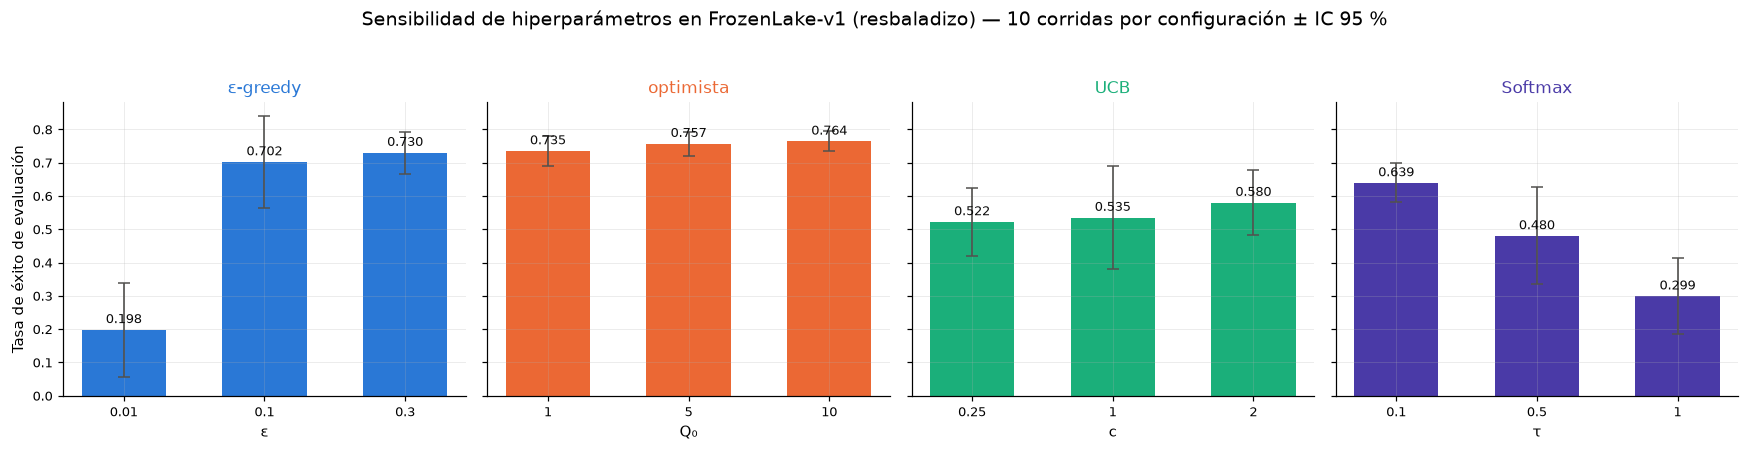

In [28]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3.9), sharey=True)
PARAM_LABEL = {"epsilon_greedy": "ε", "optimistic": "Q₀", "ucb": "c", "softmax": "τ"}

for ax, strategy_name in zip(axes, SENSITIVITY_GRID):
    block = sens_summary[sens_summary["strategy"] == strategy_name]
    color = STRATEGY_COLORS[strategy_name]
    positions = np.arange(len(block))
    ax.bar(positions, block["media"], width=0.6, color=color,
           yerr=block["ic95"], capsize=4,
           error_kw={"ecolor": "#52514e", "elinewidth": 1.1})
    for pos, value in zip(positions, block["media"]):
        ax.text(pos, value + 0.02, f"{value:.3f}", ha="center", fontsize=8.5, color="#0b0b0b")
    ax.set_xticks(positions)
    ax.set_xticklabels([f"{v:g}" for v in block["valor"]])
    ax.set_xlabel(PARAM_LABEL[strategy_name])
    ax.set_title(STRATEGY_LABELS[strategy_name].split(" (")[0], color=color)

axes[0].set_ylabel("Tasa de éxito de evaluación")
fig.suptitle(
    f"Sensibilidad de hiperparámetros en {ENV_LABELS[SENSITIVITY_ENV]} — "
    f"{SENSITIVITY_RUNS} corridas por configuración ± IC 95 %",
    fontsize=12.5, y=1.04,
)
fig.tight_layout()
plt.show()

#### Cómo funciona · Sensibilidad

**El entorno se elige con datos.** En vez de decidir a ojo cuál es "el más interesante", se toma
el que presenta mayor dispersión de éxito entre las cuatro estrategias — donde la elección de
mecanismo de exploración más cambia el resultado, que es donde vale la pena estudiar sus
parámetros.

**Todo lo demás queda congelado.** Episodios, `α`, `γ` y las semillas son idénticos entre
configuraciones; solo se mueve el hiperparámetro bajo estudio. Sin eso no podrías atribuirle a
`c` o a `τ` la diferencia observada.

**Cada panel usa el color de su estrategia** — el mismo de las figuras 1 a 3 — para que puedas
saltar entre figuras sin volver a aprender la leyenda. Dentro de un panel las tres barras son la
misma estrategia con distinto parámetro, así que el color no varía: lo que varía es el eje x.

**Cómo leerlo.** La forma del panel importa más que el ganador: un panel plano significa que la
estrategia es **robusta** a ese parámetro; uno con mucha pendiente significa que su desempeño
depende de afinarlo, y eso es una desventaja práctica cuando no puedes probar veinte valores.
Las barras de error mandan: si las tres se solapan, no hay evidencia para elegir uno.

**Sobre las 10 corridas.** Menos que las 30 del experimento principal, así que los intervalos
salen más anchos (con `n = 10` el multiplicador t es 2.262 contra 2.045). Es el mínimo que pide
el §12 y el precio de recorrer 12 configuraciones.

## 10. Interpretación

Responda citando valores, tablas o figuras del notebook:

1. ¿Qué estrategia aprendió más rápido en cada entorno? R/ Por pendiente inicial e-greedy y UCB se dispara a partir de los 750 episodios en frozenlake con isslippery. En taxi todas parecen subir parejo, solo ocn softmax desempenandose peor y con AUC -74.174, penalizandola en la etapa de entrenamiento por tener 500 episodios. En blackjack todas son aplanadas
2. ¿La estrategia con mejor curva de entrenamiento produjo también la mejor política greedy?En frozenlake es correcto decir que optimista produce la mejor curva de entrenamiento y el mejor retorno con retorno_ultimo_10pct=0.682 AUC=0.463 y retorno_eval=0.733. en taxi se comparo el nivel final de entrenamiento (retorno_ultimo_10pct) contra la política greedy (retorno_eval), porque ambas miden al agente maduro. En FrozenLake coinciden (optimista gana ambas). En Taxi, el ganador por nivel final (UCB) coincide con el de evaluación, pero si en cambio midiera velocidad de aprendizaje (auc_retorno), la ganadora sería optimista que resulta ser la peor en evaluación. Esto muestra que la respuesta depende de qué se entienda por mejor curva nivel final o velocidad. En blackjack todas las politicas tienen algo y es que estan muy cerca la una d ela otra por el intervalo de confianza y se solapan. pero por nivel final e/greedy y ucb empatan con -0.113 ambas. por velocidad greedy con AUC  -0.129 en evaluacion greedy y UCB quedan casi igual pero todos los intervalos de  confianza se solapan 
3. ¿Dónde ayudó y dónde perjudicó la inicialización optimista? Relaciónelo con recompensas negativas y estados poco visitados. Yo arranque con Q= 5. COmo todo parece bueno los agentes se ven obligados a probar cada accion hasta que corrige esta expectativa. En el caso de taxi que tienen penalizaciones altas al dejar un pasajero mal o hacer un movimiento ilegal esto hace que tome decisiones malas hasta que corrige hacia el valor verdadero de elegir esos estasdo, pese a esto en el entrenamiento se desempeno mejor que las otras con auc_reotrno = -50.269 pero con un retorno de evaluacion de -41.241 (UCB logro -8.1) y un promedio de pasos peor que todos los otros. al tener tambien tantos estados  muchos se visitaron pocas veces siguen con el inicio optimista 5 de Q, lo que hace que greedy elija una accion probablemente mala pero basandose en el valor optimista del inicio. en blackjack directamente todos son malos. y es la peor en en AUC retorno y Retorno eval
4. ¿Cómo se comportó UCB cuando muchos pares estado–acción fueron visitados pocas veces? El bono de exploraxcion de UCB todavia me confunde pero segun lo que entiendo al N(s,a) ser pequeno (poco visitado) el bono se agranda. Entonces ucb invita al agente a visitar estadr que no han sido tan cubiertos o no visitado, en consecuencia en frozenlake queda de ultimo en auc que aprende lento pero al final el retorno ultimno fue el segundo mejor con 0.417. En taxi es el ganador en resultados con retorno_ultimo_10 de 7.33, retorno_eval y longitud eval, osea que en el entrenamiento cubre mas por que al tener un bono que permite explorar casi todo a la hora de explotar se dispara y termina teniendo el mejor retorno y la menor cantidad de pasos (27.5). Blackjack me comio y solo veo que se desempenan parecido
5. ¿Qué efecto tuvo la temperatura de Softmax sobre estabilidad y desempeño? en frozenlake menor temperatura t=0.10 dio mayor media de exito, la vuelve por decirlo asi mas codiciosa, y se puede ver en el efecto inverso en la media de exito a medida que se aumenta la temperatura siendo la media de exito 0.639 y 0.299 para t=0.10 y t=1 respectivamente. Aca tiene sentido porque el isslippery anade un grado de difiultad al diluir la probabilidad de que haga la accion en 1/3 lo que hace que las politicas greedy sean mucho mas favorecidad, es deci, t bajo.en la grafica de 30 corridas se puede ver que softmax nunca despega. en taxi se ve que softmax si converge pero solo al final.
6. ¿Qué estrategia fue más sensible a la estocasticidad de FrozenLake? El patrón la sensibilidad a la estocasticidad depende de cuánto se apoya la estrategia en la calidad de la señal. Softmax depende enteramente de que los Q se separen el ruido la mata. UCB depende de conteos fieles  el ruido la ralentiza. greedy y optimista tienen exploración estructural (aleatoria fija / optimismo inicial) que no depende de la señal limpia resisten. La más sensible es softmax. la más robusta, optimista. Aca nunca se corrio con el slippery como false o apagado 
7. En Blackjack, ¿qué diferencias aparecen entre manos con y sin as utilizable? Blackkjack claremente me hizo sufir un monton, por ende si soy honesto solo le dije al agente claude code en este caso que simulara los resultados en base a esto pero no lo quise poner en el notebook, ya que no lo entendia del todo bien. Su respuesta fue la siguiente la cual me parece alineada con lo que vi durante todo el challenge:La política aprendida es mucho más agresiva cuando hay un as utilizable. El agente pide carta hasta sumas notablemente más altas antes de plantarse:

Umbral medio de plantarse: 15.1 sin as → 19.2 con as, una diferencia de 4.1 puntos.
Proporción de decisiones que dicen "pedir": 35 % sin as → 72 % con as, más del doble.
Sin as, el umbral además depende mucho de la carta del crupier (13 contra un 6 débil, 17 contra un 10 o un as). Con as utilizable el umbral es casi constante en 19-20 sin importar qué muestre el crupier.
La razón es que un as utilizable elimina el riesgo de pasarse. Mientras el as cuente como 11, cualquier carta que te pase de 21 hace que el as se recalcule como 1 y la mano se salva: con A+6 = 17, pedir un 8 no da 25 sino 18. Pedir carta es gratis. Sin as, pedir con 16 te elimina en el acto con cualquier carta de 6 o más, y por eso el agente se planta antes y se vuelve sensible a lo amenazante que sea la carta del crupier.

Y por eso la observación de Blackjack es una tupla y no un número. Las manos con y sin as requieren políticas distintas para la misma suma: con 18 el agente se planta si no hay as y sigue pidiendo si lo hay. Si el estado no incluyera esa bandera, la tabla Q mezclaría ambos casos en la misma fila y sería incapaz de representar la política correcta, por bien que explorara.
8. ¿Existe una estrategia ganadora para los tres escenarios y todas las métricas? No, en fronzenlake ya vimos que los greedy se desempen mejor, incluso optimista gano en 4 de las 5 metricas principales, ret_últ_10pct,,auc_retorno, retorno_eval,exito_eval	 pero e greedy le gana en llegar mas rapido a la meta con longitud_eval= 40.5. En taxi UCB gana en 4 metricas tambien respectivamente ret_últ_10pct,longitud_eval, retorno_eval,exito_eval pero como vimos en las graficas, en AUC gana optimista con -50.3 es decir aprende mas rapido. en resumen no hay una politica universal y depende mucho de que se busque, si velocidad, precision, el entorno tambien. En blackjack en una metrica ret_ult_10 empatan greedy y ucb 
9. Si el costo de interacción fuera alto, ¿qué estrategia recomendaría y por qué? optimista, porque combina las dos propiedades que un presupuesto limitado exige explora duro temprano y detiene la exploracion y gana auc_retorno en los dos entornos donde hay algo que aprender. La excepción es cuando las recompensas son mayoritariamente negativas, donde su optimismo se vuelve contraproducente y conviene e-greedy. La clave es que con costo alto se optimiza el camino (AUC), no el destino (retorno final). Por ejemplo como vimos con frozenlake UCB tiene un auc menor porque el bono lo obliga a explorar, generando peligro de caerse. greedy explora un 10% asi ya tenga la respuesta y softmax en txi y frozenlake tiene el peor desempeno en AUC, gasta muchas iteraciones para poder aprender
10. Mencione dos amenazas a la validez del experimento.
la primera y me la dio la IA es que en blackjack uno tambien podria definir empate con una recompensa ya que se puede interpretar como no perder, lo cual me parece valido y valdria la pena experimentarlo y para taxi se definio la recompensa como entregar el pasajero, osea independiente de los pasos, si se tuviera en cuenta el numero de pasos requeridos para lograr el objetivo, seria otro el panorama. La sensibilidad solo la medi en frozenlake y vimos que softmax respondio mucho mejor con t=0.10 lo que para la corrida grande de 30 episodios pudo haber traido algo distino. otra cosa notable es que en la corrida 1 de 100 episodios para frozenlake con semilla 2026 ucb se colapsa despues del episodio 1750 y no se si esto fue por la semilla o que pero varias veces corri la celda con el mismo resultado.

## 11. Uso de inteligencia artificial

**Herramienta(s):**  
**Prompts principales:**  
1. hacer el notebook explicando codigo y como leer las graficas.
2. el laboratorio donde yo puedo meter los parametros para los 4 experimientos y moverlos para cada politca me parecio muy interesante aunque al principio me confundio https://github.com/Tejada90/rl-course_EIA_20262/blob/challenge-01-simon-garces/challenges/challenge_03_qlearning_exploration/submission/laboratorio_exploracion_garces_simon.html 

**Sugerencias aceptadas o rechazadas y por qué:** TODO  
**Cambios manuales:** TODO  
**Cómo se verificó el código y la interpretación:** TODO


## 12. Conclusiones

Redacte entre cuatro y seis conclusiones sustentadas en resultados. Evite repetir definiciones o afirmar causalidad sin evidencia.

1. La primera es que me demore mucho entendiendo como la IA dividio el reto en los 30 episodios y que cada episodio eran 2000 tiradas, por eso casi no le cojo la logica. Tamnbien la eleccion de los nombres de las variables me jugo en contra, porque retorno_ult_10Ppct no dice una mierda, dice mas exito, o final de entrenamiento. por eso fue un grave error decirle al agente que hiciera esto en un solo tiro, porque me tomo mas tiempo desenredar lo que hizo que simplemente construirlo de a poco y progresivamente
2. El ganador cambió según el entorno optimista fue el mejor en FrozenLake (retorno de evaluación de 0.733), UCB en Taxi (−8.120, muy por encima del −41.241 de optimista) y en Blackjack no ganó nadie, porque los intervalos de confianza se solapan entre todas las estrategias. FrozenLake premia a las estrategias que explotan pronto por dos razones: es un entorno chico (16 estados) y es resbaladizo, así que la acción que el agente elige solo se ejecuta un tercio de las veces. Con ese nivel de azar, explorar mas  cada paso aleatorio tiene buena probabilidad de terminar en un hueco, así que insistir en la mejor acción conocida rinde más. La conclusión de fondo es que ninguna estrategia fue mejor por sí sola el ganador dependió de cómo estaba armado el entorno.
3. Aprender rápido no significa terminar mejor. El caso más claro es optimista en Taxi: fue el que más rápido aprendió (el mejor auc_retorno, −50.269) pero el peor a la hora de evaluar su política (−41.241). UCB fue lo contrario: aprendió más lento (−52.742) pero como su bono por visitas lo lleva a recorrer todo el espacio de estados, terminó con la mejor política de evaluación (−8.120). Por eso hay que mirar las dos métricas por aparte, la del camino (AUC) y la del resultado final (evaluación greedy): pueden apuntar a estrategias distintas, y quedarse solo con una da una lectura incompleta.
4. Cada estrategia depende de una condición estructural distinta para funcionar optimista necesita recompensas positivas que persigan sus expectativas infladas hacia abajo, softmax necesita que los valores Q se separen para elegir bien, algo que la recompensa escasa y el hielo resbaladizo de FrozenLake le impiden (por eso quedó plana en 0.021); UCB necesita que sus conteos de visitas sean fieles al espacio explorado, y e greedy es el más robusto pero desperdicia interacciones al explorar un porcentaje fijo aun cuando ya conoce la respuesta. La consecuencia es que no existe un modelo superior en sí mismo existe la mejor elección para un entorno y un objetivo dados. El humano debe decidir qué prioriza —velocidad de aprendizaje, retorno final, robustez o eficiencia de interacción— y elegir en consecuencia.

Qué cambié y por qué: no hice la parte del as con blackjack porque realmente blackjack fue el que estadisticamente mas me reto para entender y las graficas no eran lo suficientemente dicientes


## Lista de verificación de entrega

- [ x] Implementé y validé las cuatro estrategias.
- [ x] Q-Learning trata correctamente estados terminales y truncamientos.
- [x ] Comparé tres entornos con semillas y presupuesto equivalentes.
- [ x] Separé entrenamiento y evaluación greedy.
- [x ] Reporté variabilidad entre corridas.
- [ x] Incluí tabla, cuatro visualizaciones y sensibilidad.
- [x ] Respondí todas las preguntas con evidencia.
- [x] Documenté el uso de IA y escribí conclusiones.
- [ x] Reinicié el kernel y ejecuté todas las celdas.
- [ ] Exporté y revisé el HTML.
